# Reflective and Catadioptric Systems

Reflective optics — mirrors — are chromatic-aberration-free and can cover large
apertures efficiently. The NSQ engine supports spherical and conic mirrors via
`MirrorConfig`, which feeds into `scene.add_mirror()`.

This notebook covers:
1. Spherical vs. parabolic mirror spot comparison
2. Solar concentrator — parabolic mirror + irradiance analysis
3. Two-mirror Cassegrain-like relay
4. Catadioptric system — combining a mirror and a refractive lens
5. Far-field radiation pattern of a reflective source

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from optiland.coordinate_system import CoordinateSystem
from optiland.nonsequential import (
    NSQScene, Spectrum,
    CollimatedSourceConfig, PointSourceConfig, ExtendedSourceConfig,
    IrradianceDetectorConfig, FarFieldDetectorConfig,
    LensConfig, MirrorConfig, SurfaceConfig,
    SpecularBRDF,
)

spec = Spectrum.monochromatic(0.55)

## 1. Mirror Sign Convention

A mirror is placed with `scene.add_mirror(name, cs, MirrorConfig(...))` and needs
**no rotation** to face a beam arriving from `−z`. What decides its shape is the
sign of `radius`, using the same convention as the rest of Optiland:

> `radius` is positive when the centre of curvature lies on the **+z** side of
> the vertex, and negative when it lies on the **−z** side.

So for a beam travelling in `+z` that you want to focus back toward `−z`
(the usual telescope-primary arrangement), the centre of curvature is behind
the beam and **`radius` is negative**:

```python
scene.add_mirror('M', CoordinateSystem(z=0),
                 MirrorConfig(radius=-200, conic=-1.0, aperture_radius=25))
# focuses a collimated +z beam at z = -100 mm
```

The focal length of a conic mirror is `f = |radius| / 2`, and the focus lies on
the same side as the centre of curvature.

<div class="alert alert-info">

Adding `rx=np.pi` flips the surface and turns this concave mirror into a
**convex** one, which diverges the beam instead of focusing it. Set the sign of
`radius` rather than rotating the mirror.

</div>


## 2. Spherical vs. Parabolic Mirror

A **spherical mirror** (`conic=0`) suffers from spherical aberration for
on-axis collimated input: marginal rays focus closer to the mirror than
paraxial rays. A **parabolic mirror** (`conic=-1`) eliminates this aberration
and focuses a collimated on-axis beam to a perfect geometrical point.

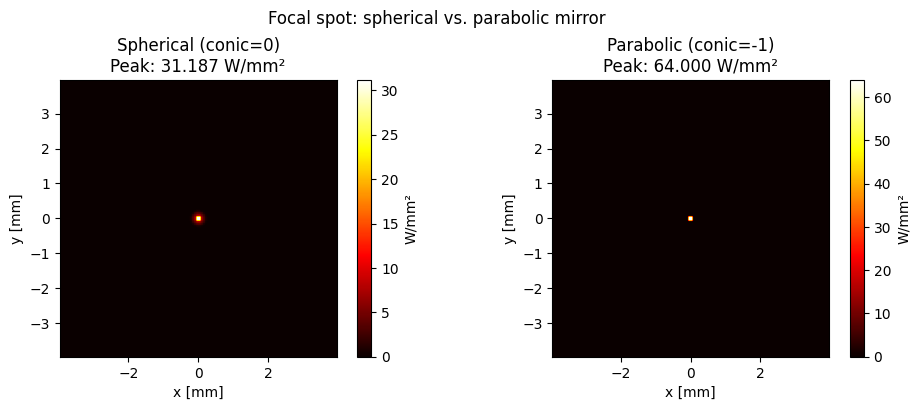

In [2]:
def mirror_spot(conic, aperture_radius=25, n_rays=40_000):
    # Focal length = 100 mm (R = -200 mm, concave toward -z)
    scene_m = NSQScene()
    scene_m.add_source(
        'S', CoordinateSystem(z=-100),
        CollimatedSourceConfig(spec, total_flux=1.0, aperture_radius=aperture_radius),
    )
    scene_m.add_mirror(
        'M', CoordinateSystem(z=0),
        MirrorConfig(radius=-200, conic=conic, aperture_radius=aperture_radius + 2),
    )
    scene_m.add_detector(
        'D', CoordinateSystem(z=-100),
        IrradianceDetectorConfig(width=8, height=8, num_pixels_x=128, num_pixels_y=128),
    )
    r = scene_m.trace(num_rays=n_rays, seed=42)
    return r.detectors['D']

irr_sphere  = mirror_spot(conic=0.0)
irr_parab   = mirror_spot(conic=-1.0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, irr, title in zip(axes, [irr_sphere, irr_parab],
                          ['Spherical (conic=0)', 'Parabolic (conic=-1)']):
    im = ax.imshow(irr.irradiance, origin='lower', cmap='hot', aspect='equal',
                   extent=[irr.x_coords[0], irr.x_coords[-1],
                            irr.y_coords[0], irr.y_coords[-1]])
    plt.colorbar(im, ax=ax, label='W/mm²')
    ax.set_title(f'{title}\nPeak: {irr.irradiance.max():.3f} W/mm²')
    ax.set_xlabel('x [mm]'); ax.set_ylabel('y [mm]')
plt.suptitle('Focal spot: spherical vs. parabolic mirror', fontsize=12)
plt.tight_layout()
plt.show()
plt.close(fig)

## 3. Solar Concentrator

A parabolic dish captures parallel solar radiation and focuses it onto a small
receiver. The concentration ratio is the peak receiver irradiance divided by the
ambient solar irradiance.

The physically important detail is that **the Sun is not a point**: it subtends
about 0.53° from Earth, so a perfect parabola images it as a disc rather than a
point, and that disc sets the achievable concentration. We model this with an
`ExtendedSource` the size of the dish, in which every point emits into a
±0.265° cone.

The resulting spot radius should come out at `f · tan(0.265°)`, the geometrical
image of the solar disc.


Flux intercepted by dish : 7.85 W
Flux on receiver         : 7.854 W (100.0% collected)
Peak concentration       : 3,168x ambient
90% encircled radius     : 0.899 mm
Solar image radius       : 0.925 mm  (f * tan(0.265 deg))


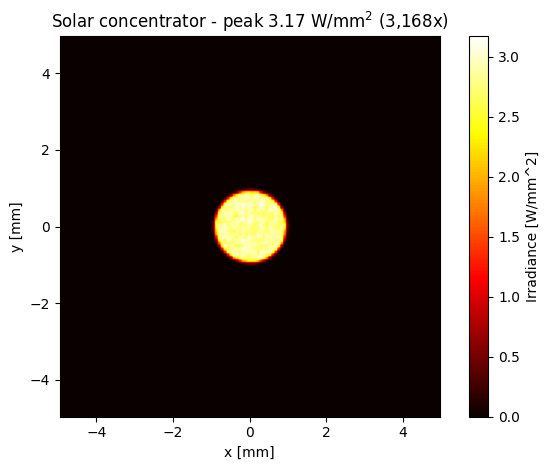

In [3]:
# Solar irradiance ~ 1000 W/m^2 = 0.001 W/mm^2
mirror_radius = 50.0
solar_flux = 0.001 * np.pi * mirror_radius**2  # W intercepted by the dish
focal_length = 200.0  # f = |radius| / 2

# Broadband solar-like spectrum (visible + NIR)
spec_solar = Spectrum(
    wavelengths=np.array([0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]),
    weights=np.array([0.6, 1.0, 1.1, 1.0, 0.9, 0.7, 0.5]),
)

scene_solar = NSQScene()
# The Sun: a disc of parallel-ish beams, each spread over the solar half-angle.
scene_solar.add_source(
    'Sun', CoordinateSystem(z=-200),
    ExtendedSourceConfig(spectrum=spec_solar, total_flux=solar_flux,
                         aperture_radius=mirror_radius,
                         half_angle_deg=0.265),   # solar disc half-angle
)
scene_solar.add_mirror(
    'Dish', CoordinateSystem(z=0),
    MirrorConfig(radius=-400, conic=-1.0, aperture_radius=mirror_radius + 2),
)
# Receiver at the focus (f = |radius| / 2 = 200 mm, on the -z side)
scene_solar.add_detector(
    'Receiver', CoordinateSystem(z=-focal_length),
    IrradianceDetectorConfig(width=10, height=10, num_pixels_x=128, num_pixels_y=128),
)

result_solar = scene_solar.trace(num_rays=120_000, seed=42)
irr_solar = result_solar.detectors['Receiver']

ambient = solar_flux / (np.pi * mirror_radius**2)
concentration = irr_solar.irradiance.max() / ambient

# Radius containing 90% of the collected flux
E = irr_solar.irradiance
X, Y = np.meshgrid(irr_solar.x_coords, irr_solar.y_coords)
R = np.hypot(X, Y)
order = np.argsort(R.ravel())
cumulative = np.cumsum(E.ravel()[order]) / E.sum()
r90 = R.ravel()[order][np.searchsorted(cumulative, 0.9)]
r_theory = focal_length * np.tan(np.radians(0.265))

print(f"Flux intercepted by dish : {solar_flux:.2f} W")
print(f"Flux on receiver         : {irr_solar.total_flux:.3f} W "
      f"({irr_solar.total_flux / solar_flux * 100:.1f}% collected)")
print(f"Peak concentration       : {concentration:,.0f}x ambient")
print(f"90% encircled radius     : {r90:.3f} mm")
print(f"Solar image radius       : {r_theory:.3f} mm  (f * tan(0.265 deg))")

fig = irr_solar.plot(cmap='hot')
plt.title(f'Solar concentrator - peak {irr_solar.irradiance.max():.2f} W/mm$^2$ '
          f'({concentration:,.0f}x)')
plt.tight_layout()
plt.show()


## 4. Catadioptric System — Mirror + Lens

A catadioptric system combines a primary reflective element with a refractive
corrector. Here we use a concave mirror as the primary and a singlet lens as a
field-correcting relay.

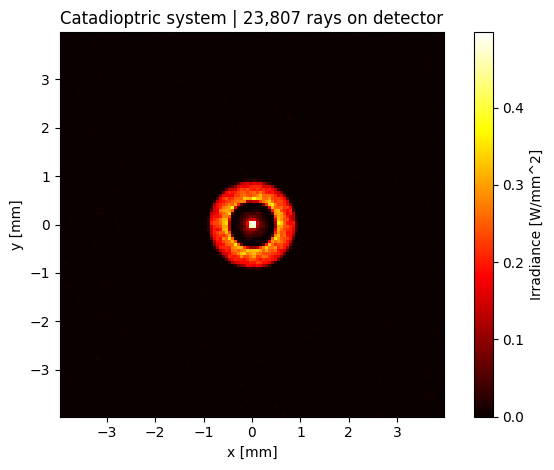

In [4]:
scene_cat = NSQScene()
scene_cat.add_source(
    'S', CoordinateSystem(z=-150),
    CollimatedSourceConfig(spec, total_flux=1.0, aperture_radius=20.0),
)
# Primary mirror: f = 75 mm
scene_cat.add_mirror(
    'PM', CoordinateSystem(z=0),
    MirrorConfig(radius=-150, conic=-1.0, aperture_radius=22.0),
)
# Field corrector lens near the focus
scene_cat.add_lens(
    'FC', CoordinateSystem(z=-50),
    LensConfig(r1=-80, r2=80, thickness=4, material='N-BK7', front_aperture_radius=15.0),
)
# Detector
scene_cat.add_detector(
    'D', CoordinateSystem(z=-90),
    IrradianceDetectorConfig(width=8, height=8, num_pixels_x=128, num_pixels_y=128),
)

result_cat = scene_cat.trace(num_rays=50_000, seed=42)
irr_cat = result_cat.detectors['D']

fig = irr_cat.plot(cmap='hot')
plt.title(f'Catadioptric system | {irr_cat.num_rays_hit:,} rays on detector')
plt.tight_layout()
plt.show()
plt.close(fig)

## 5. Far-Field Radiation Pattern

A `FarFieldDetector` bins rays by direction rather than position, giving the
**angular distribution** of the light leaving the system.

A point source exactly at the focus of a perfect parabola would collimate to
zero divergence, which is not informative. A real emitter has finite size, and
that size sets the divergence:

$$\theta_{\mathrm{FWHM}} \approx 2\arctan\left(\frac{r_{\mathrm{source}}}{f}\right)$$

Below, a 5 mm-radius emitter at the focus of a 100 mm parabola should give about
5.7° of divergence. This is the fundamental etendue trade: a bigger source
cannot be collimated as tightly.


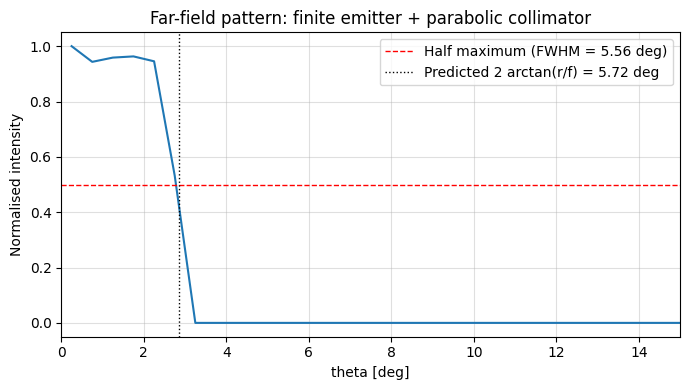

Measured FWHM  : 5.56 deg
Predicted FWHM : 5.72 deg  (2 arctan(r_source / f))


In [5]:
# Finite-size emitter at the focus of a parabolic collimator
led_radius = 5.0     # mm
focal_length = 100.0  # f = |radius| / 2 = 200 / 2

scene_farfield = NSQScene()
scene_farfield.add_source(
    'LED', CoordinateSystem(z=-focal_length),      # at the mirror focus
    ExtendedSourceConfig(spectrum=spec, total_flux=1.0,
                         aperture_radius=led_radius, half_angle_deg=90),
)
scene_farfield.add_mirror(
    'PM', CoordinateSystem(z=0),
    MirrorConfig(radius=-200, conic=-1.0, aperture_radius=30.0),
)
# Fine theta bins: the beam is only a few degrees wide
scene_farfield.add_detector(
    'FF', CoordinateSystem(z=-150),
    FarFieldDetectorConfig(num_theta=180, num_phi=180),
)

result_ff = scene_farfield.trace(num_rays=150_000, seed=42)
ff = result_ff.detectors['FF']

# Azimuthally averaged radial profile
radial = ff.intensity.sum(axis=1)
profile = radial / radial.max()


def fwhm_deg(theta, profile):
    """Full width at half maximum, interpolated on the falling edge."""
    above = np.where(profile >= 0.5)[0]
    if len(above) < 2:
        return 0.0
    i = above[-1]
    if i + 1 < len(profile):
        frac = (profile[i] - 0.5) / (profile[i] - profile[i + 1])
        edge = theta[i] + frac * (theta[i + 1] - theta[i])
    else:
        edge = theta[i]
    return 2.0 * edge   # profile is symmetric about theta = 0


measured = fwhm_deg(ff.theta, profile)
predicted = 2.0 * np.degrees(np.arctan(led_radius / focal_length))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ff.theta, profile, lw=1.5)
ax.axhline(0.5, color='r', ls='--', lw=1,
           label=f'Half maximum (FWHM = {measured:.2f} deg)')
ax.axvline(predicted / 2, color='k', ls=':', lw=1,
           label=f'Predicted 2 arctan(r/f) = {predicted:.2f} deg')
ax.set_xlim(0, 15)
ax.set_xlabel('theta [deg]')
ax.set_ylabel('Normalised intensity')
ax.set_title('Far-field pattern: finite emitter + parabolic collimator')
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"Measured FWHM  : {measured:.2f} deg")
print(f"Predicted FWHM : {predicted:.2f} deg  (2 arctan(r_source / f))")


## Summary

- `MirrorConfig(radius, conic, aperture_radius)` — conic constant: 0 = sphere, −1 = paraboloid
- A mirror needs **no rotation** to face an incoming `+z` beam; the sign of
  `radius` sets whether it is concave (`radius < 0` here) or convex
- Focal length of a mirror: `f = |radius| / 2`
- Parabolic mirrors eliminate on-axis spherical aberration for collimated input;
  spherical mirrors do not, and the residual blur grows with aperture
- Mix `add_mirror` and `add_lens` in the same scene for catadioptric systems
- `FarFieldDetector` measures beam divergence (FWHM) and angular distribution
